# FactorBuilder v1.2 — Feature Engineering for ML

## Purpose
Generates a **wide feature matrix** from Yahoo Consensus time series data for machine learning model training.

## Input
- All `*_YahooConsensus.csv` files in the folder
- Filters to tickers with >= 5 analysts (`MIN_ANALYSTS`)

## Output Files
1. **Main Dataset:** `YYYYMMDD_YahooConsensus_FactorDataset.csv`  
   Wide matrix with one row per (Date, Ticker) combination

2. **Per-Ticker CSVs:** `{TICKER}_FactorDataset.csv` (one file per ticker)  
   Individual time series for inspection/debugging

---

## Feature Categories

### **1. Past Revision Features** (lookback: 1W, 2W, 1M, 3M, 6M)
For each window:
- **TP changes:** `Past_{window}_TP_{Min/Avg/Max}_Change`  
  How target price (min/avg/max) changed vs {window} ago

- **Revenue Y1/Y2 changes:** `Past_{window}_Y1_Rev_{Min/Avg/Max}_Change`  
  Revenue estimate changes for FY1 and FY2

- **EPS Y1/Y2 changes:** `Past_{window}_Y1_EPS_{Min/Avg/Max}_Change`  
  EPS estimate changes for FY1 and FY2

- **Price changes:** `Past_{window}_Price_Change`  
  Actual stock price movement

### **2. Dispersion Features** (analyst disagreement)
- `TP_Dispersion` = (TP_Max - TP_Min) / TP_Avg  
  High = analysts disagree on target price

- `Rev_Y1_Dispersion` = (Rev_Y1_Max - Rev_Y1_Min) / Rev_Y1_Avg
- `EPS_Y1_Dispersion` = (EPS_Y1_Max - EPS_Y1_Min) / EPS_Y1_Avg
- Same for Y2

### **3. Interaction Features** (divergences)
Computed for each window:
- `{window}_TP_Rev_Spread` = TP_Avg_Change - Rev_Avg_Change  
  Are analysts more optimistic about price than revenue?

- `{window}_Rev_EPS_Spread` = Rev_Avg_Change - EPS_Avg_Change  
  Revenue momentum vs earnings momentum

- `{window}_Price_Estimate_Divergence` = Price_Change - TP_Avg_Change  
  Is price moving differently than analyst estimates?

### **4. Acceleration Features** (2nd derivative)
- `TP_Accel_2W_vs_1W` = Past_2W_TP_Change - Past_1W_TP_Change  
  Positive = revisions decelerating (2W weaker than 1W)  
  Negative = revisions accelerating (2W stronger than 1W)

- `TP_Accel_1M_vs_2W` = Past_1M_TP_Change - Past_2W_TP_Change
- `TP_Accel_3M_vs_1M` = Past_3M_TP_Change - Past_1M_TP_Change
- `TP_Accel_6M_vs_3M` = Past_6M_TP_Change - Past_3M_TP_Change
- Same pattern for Rev and EPS

### **5. Target Variables** (forward returns to predict)
- `Fwd_2W_Price_Change` — 2-week forward return
- `Fwd_1M_Price_Change` — 1-month forward return
- `Fwd_3M_Price_Change` — 3-month forward return

---

## Use Cases
1. **Train ML models** to predict forward returns from estimate revision patterns
2. **Feature importance analysis** to understand what drives stock prices
3. **Backtest strategies** based on revision signals
4. **Inspect individual ticker** time series via per-ticker CSVs

---

## Key Parameters
- `MIN_ANALYSTS = 5` — minimum analyst count
- `WINDOWS = ["1W", "2W", "1M", "3M", "6M"]` — lookback periods
- `EXPORT_PER_TICKER = True` — generate individual ticker CSVs

---

## Notes
- Missing data handled as `NaN` (not forward-filled to avoid lookahead bias)
- FIN Yr changes tracked: Y1 and Y2 determined per date (earliest two FIN Yrs)
- All changes calculated as: `current / past - 1` (percentage change)
- Forward returns may be `NaN` for recent dates (no future data yet)

In [2]:
import pandas as pd
import glob
import numpy as np
import os
from datetime import timedelta
from dateutil.relativedelta import relativedelta

# ================= CONFIG =================
FOLDER = r"C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\ResearchReports\YahooConsensus"

MIN_ANALYSTS = 5
EXCLUDE_TICKERS = []  # e.g. ["YESBANK", "IDEA"]
EXPORT_PER_TICKER = True  # Set False to skip per-ticker CSV generation

# Lookback windows (added 6M)
WINDOWS = [
    ("1W", {"weeks": 1}),
    ("2W", {"weeks": 2}),
    ("1M", {"months": 1}),
    ("3M", {"months": 3}),
    ("6M", {"months": 6}),
]

# ================= HELPERS =================
def get_asof_past(dates, target_date):
    eligible = dates[dates <= target_date]
    return eligible.max() if not eligible.empty else None

def get_asof_future(dates, target_date):
    eligible = dates[dates >= target_date]
    return eligible.min() if not eligible.empty else None

def shift_back(date, weeks=0, months=0):
    d = date
    if weeks:
        d = d - timedelta(weeks=weeks)
    if months:
        d = d - relativedelta(months=months)
    return d

def shift_forward(date, weeks=0, months=0):
    d = date
    if weeks:
        d = d + timedelta(weeks=weeks)
    if months:
        d = d + relativedelta(months=months)
    return d

def safe_ratio(num, den):
    if pd.isna(num) or pd.isna(den) or den == 0:
        return np.nan
    return round(num / den - 1, 4)

def safe_dispersion(min_val, max_val, avg_val):
    """(Max - Min) / Avg"""
    if pd.isna(min_val) or pd.isna(max_val) or pd.isna(avg_val) or avg_val == 0:
        return np.nan
    return round((max_val - min_val) / avg_val, 4)

# ================= LOAD ALL CSVs =================
files = sorted(glob.glob(f"{FOLDER}\\*_YahooConsensus.csv"))
if not files:
    raise FileNotFoundError("No *_YahooConsensus.csv files found in folder.")

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["Date"] = pd.to_datetime(df["Date"])
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all[df_all["#Count"] >= MIN_ANALYSTS].copy()

if EXCLUDE_TICKERS:
    df_all = df_all[~df_all["YAHOO Ticker"].isin(EXCLUDE_TICKERS)].copy()

df_all.sort_values(["Date", "YAHOO Ticker", "FIN Yr"], inplace=True)
df_all.reset_index(drop=True, inplace=True)

# Unique dates
all_dates = pd.Series(sorted(df_all["Date"].unique()))
latest_date = all_dates.iloc[-1]
latest_date_str = latest_date.strftime("%Y%m%d")
output_file = f"{FOLDER}\\{latest_date_str}_YahooConsensus_FactorDataset.csv"
per_ticker_folder = f"{FOLDER}\\PerTickerDatasets"

if EXPORT_PER_TICKER:
    os.makedirs(per_ticker_folder, exist_ok=True)

# Precompute price panel
price_panel = df_all.groupby(["Date", "YAHOO Ticker"])["Current Price"].first().unstack()
group_dt = df_all.groupby(["Date", "YAHOO Ticker"])

print(f"Loaded {len(files)} CSV files")
print(f"Date range: {all_dates.iloc[0].date()} to {all_dates.iloc[-1].date()}")
print(f"Total tickers: {df_all['YAHOO Ticker'].nunique()}")
print(f"Total (Date, Ticker) combinations: {len(df_all.groupby(['Date', 'YAHOO Ticker']))}")
print(f"\nGenerating features...")

rows = []

# ================= MAIN LOOP =================
for date_idx, current_date in enumerate(all_dates):
    if (date_idx + 1) % 5 == 0 or date_idx == 0:
        print(f"  Processing date {date_idx+1}/{len(all_dates)}: {current_date.date()}")
    
    tickers_today = df_all.loc[df_all["Date"] == current_date, "YAHOO Ticker"].unique()

    # Precompute past and future dates for all windows
    past_dates = {}
    for label, kwargs in WINDOWS:
        past_dates[label] = get_asof_past(all_dates, shift_back(current_date, **kwargs))

    # Forward dates for targets
    f2w_date = get_asof_future(all_dates, shift_forward(current_date, weeks=2))
    f1m_date = get_asof_future(all_dates, shift_forward(current_date, months=1))
    f3m_date = get_asof_future(all_dates, shift_forward(current_date, months=3))

    for ticker in tickers_today:
        # ---------- CURRENT SNAPSHOT ----------
        try:
            df_curr = group_dt.get_group((current_date, ticker))
        except KeyError:
            continue

        fin_years_curr = sorted(df_curr["FIN Yr"].unique())
        if len(fin_years_curr) == 0:
            continue

        Y1 = fin_years_curr[0]
        Y2 = fin_years_curr[1] if len(fin_years_curr) > 1 else None

        def get_row_for_fy(df, fy):
            sub = df[df["FIN Yr"] == fy]
            return sub.iloc[0] if not sub.empty else None

        row_y1_curr = get_row_for_fy(df_curr, Y1)
        row_y2_curr = get_row_for_fy(df_curr, Y2) if Y2 is not None else None

        base_row = df_curr.iloc[0]
        tp_min_curr = base_row["TP(Min)"]
        tp_avg_curr = base_row["TP(Avg)"]
        tp_max_curr = base_row["TP(Max)"]
        analyst_count = base_row["#Count"]

        # Current price
        price_0 = price_panel.loc[current_date, ticker] if ticker in price_panel.columns else np.nan

        # ---------- DISPERSION FEATURES (current snapshot) ----------
        tp_dispersion = safe_dispersion(tp_min_curr, tp_max_curr, tp_avg_curr)

        rev_y1_dispersion = np.nan
        eps_y1_dispersion = np.nan
        rev_y2_dispersion = np.nan
        eps_y2_dispersion = np.nan

        if row_y1_curr is not None:
            rev_y1_dispersion = safe_dispersion(
                row_y1_curr["Rev.(Min)"], row_y1_curr["Rev.(Max)"], row_y1_curr["Rev.(Avg)"]
            )
            eps_y1_dispersion = safe_dispersion(
                row_y1_curr["EPS(Min)"], row_y1_curr["EPS(Max)"], row_y1_curr["EPS(Avg)"]
            )

        if row_y2_curr is not None:
            rev_y2_dispersion = safe_dispersion(
                row_y2_curr["Rev.(Min)"], row_y2_curr["Rev.(Max)"], row_y2_curr["Rev.(Avg)"]
            )
            eps_y2_dispersion = safe_dispersion(
                row_y2_curr["EPS(Min)"], row_y2_curr["EPS(Max)"], row_y2_curr["EPS(Avg)"]
            )

        # ---------- PAST REVISION FEATURES (all windows) ----------
        past_features = {}

        for label, kwargs in WINDOWS:
            p_date = past_dates[label]

            # Initialize all to NaN
            past_features[f"Past_{label}_TP_Min_Change"] = np.nan
            past_features[f"Past_{label}_TP_Avg_Change"] = np.nan
            past_features[f"Past_{label}_TP_Max_Change"] = np.nan

            past_features[f"Past_{label}_Y1_Rev_Min_Change"] = np.nan
            past_features[f"Past_{label}_Y1_Rev_Avg_Change"] = np.nan
            past_features[f"Past_{label}_Y1_Rev_Max_Change"] = np.nan
            past_features[f"Past_{label}_Y1_EPS_Min_Change"] = np.nan
            past_features[f"Past_{label}_Y1_EPS_Avg_Change"] = np.nan
            past_features[f"Past_{label}_Y1_EPS_Max_Change"] = np.nan

            past_features[f"Past_{label}_Y2_Rev_Min_Change"] = np.nan
            past_features[f"Past_{label}_Y2_Rev_Avg_Change"] = np.nan
            past_features[f"Past_{label}_Y2_Rev_Max_Change"] = np.nan
            past_features[f"Past_{label}_Y2_EPS_Min_Change"] = np.nan
            past_features[f"Past_{label}_Y2_EPS_Avg_Change"] = np.nan
            past_features[f"Past_{label}_Y2_EPS_Max_Change"] = np.nan

            past_features[f"Past_{label}_Price_Change"] = np.nan

            if p_date is None:
                continue

            # Get past snapshot
            try:
                df_past = group_dt.get_group((p_date, ticker))
            except KeyError:
                continue

            base_past = df_past.iloc[0]

            # TP changes
            past_features[f"Past_{label}_TP_Min_Change"] = safe_ratio(tp_min_curr, base_past["TP(Min)"])
            past_features[f"Past_{label}_TP_Avg_Change"] = safe_ratio(tp_avg_curr, base_past["TP(Avg)"])
            past_features[f"Past_{label}_TP_Max_Change"] = safe_ratio(tp_max_curr, base_past["TP(Max)"])

            # Y1 changes
            row_y1_past = get_row_for_fy(df_past, Y1)
            if row_y1_curr is not None and row_y1_past is not None:
                past_features[f"Past_{label}_Y1_Rev_Min_Change"] = safe_ratio(
                    row_y1_curr["Rev.(Min)"], row_y1_past["Rev.(Min)"]
                )
                past_features[f"Past_{label}_Y1_Rev_Avg_Change"] = safe_ratio(
                    row_y1_curr["Rev.(Avg)"], row_y1_past["Rev.(Avg)"]
                )
                past_features[f"Past_{label}_Y1_Rev_Max_Change"] = safe_ratio(
                    row_y1_curr["Rev.(Max)"], row_y1_past["Rev.(Max)"]
                )
                past_features[f"Past_{label}_Y1_EPS_Min_Change"] = safe_ratio(
                    row_y1_curr["EPS(Min)"], row_y1_past["EPS(Min)"]
                )
                past_features[f"Past_{label}_Y1_EPS_Avg_Change"] = safe_ratio(
                    row_y1_curr["EPS(Avg)"], row_y1_past["EPS(Avg)"]
                )
                past_features[f"Past_{label}_Y1_EPS_Max_Change"] = safe_ratio(
                    row_y1_curr["EPS(Max)"], row_y1_past["EPS(Max)"]
                )

            # Y2 changes
            if Y2 is not None:
                row_y2_past = get_row_for_fy(df_past, Y2)
                if row_y2_curr is not None and row_y2_past is not None:
                    past_features[f"Past_{label}_Y2_Rev_Min_Change"] = safe_ratio(
                        row_y2_curr["Rev.(Min)"], row_y2_past["Rev.(Min)"]
                    )
                    past_features[f"Past_{label}_Y2_Rev_Avg_Change"] = safe_ratio(
                        row_y2_curr["Rev.(Avg)"], row_y2_past["Rev.(Avg)"]
                    )
                    past_features[f"Past_{label}_Y2_Rev_Max_Change"] = safe_ratio(
                        row_y2_curr["Rev.(Max)"], row_y2_past["Rev.(Max)"]
                    )
                    past_features[f"Past_{label}_Y2_EPS_Min_Change"] = safe_ratio(
                        row_y2_curr["EPS(Min)"], row_y2_past["EPS(Min)"]
                    )
                    past_features[f"Past_{label}_Y2_EPS_Avg_Change"] = safe_ratio(
                        row_y2_curr["EPS(Avg)"], row_y2_past["EPS(Avg)"]
                    )
                    past_features[f"Past_{label}_Y2_EPS_Max_Change"] = safe_ratio(
                        row_y2_curr["EPS(Max)"], row_y2_past["EPS(Max)"]
                    )

            # Price change
            if p_date in price_panel.index and ticker in price_panel.columns:
                price_past = price_panel.loc[p_date, ticker]
                past_features[f"Past_{label}_Price_Change"] = safe_ratio(price_0, price_past)

        # ---------- INTERACTION FEATURES (per window) ----------
        interaction_features = {}
        for label, _ in WINDOWS:
            tp_chg = past_features.get(f"Past_{label}_TP_Avg_Change", np.nan)
            rev_chg = past_features.get(f"Past_{label}_Y1_Rev_Avg_Change", np.nan)
            eps_chg = past_features.get(f"Past_{label}_Y1_EPS_Avg_Change", np.nan)
            price_chg = past_features.get(f"Past_{label}_Price_Change", np.nan)

            # TP vs Rev spread
            if pd.notna(tp_chg) and pd.notna(rev_chg):
                interaction_features[f"{label}_TP_Rev_Spread"] = round(tp_chg - rev_chg, 4)
            else:
                interaction_features[f"{label}_TP_Rev_Spread"] = np.nan

            # Rev vs EPS spread
            if pd.notna(rev_chg) and pd.notna(eps_chg):
                interaction_features[f"{label}_Rev_EPS_Spread"] = round(rev_chg - eps_chg, 4)
            else:
                interaction_features[f"{label}_Rev_EPS_Spread"] = np.nan

            # Price vs Estimate divergence
            if pd.notna(price_chg) and pd.notna(tp_chg):
                interaction_features[f"{label}_Price_Estimate_Divergence"] = round(price_chg - tp_chg, 4)
            else:
                interaction_features[f"{label}_Price_Estimate_Divergence"] = np.nan

        # ---------- ACCELERATION FEATURES (2nd derivative) ----------
        accel_features = {}

        # TP acceleration
        tp_1w = past_features.get("Past_1W_TP_Avg_Change", np.nan)
        tp_2w = past_features.get("Past_2W_TP_Avg_Change", np.nan)
        tp_1m = past_features.get("Past_1M_TP_Avg_Change", np.nan)
        tp_3m = past_features.get("Past_3M_TP_Avg_Change", np.nan)
        tp_6m = past_features.get("Past_6M_TP_Avg_Change", np.nan)

        accel_features["TP_Accel_2W_vs_1W"] = round(tp_2w - tp_1w, 4) if pd.notna(tp_2w) and pd.notna(tp_1w) else np.nan
        accel_features["TP_Accel_1M_vs_2W"] = round(tp_1m - tp_2w, 4) if pd.notna(tp_1m) and pd.notna(tp_2w) else np.nan
        accel_features["TP_Accel_3M_vs_1M"] = round(tp_3m - tp_1m, 4) if pd.notna(tp_3m) and pd.notna(tp_1m) else np.nan
        accel_features["TP_Accel_6M_vs_3M"] = round(tp_6m - tp_3m, 4) if pd.notna(tp_6m) and pd.notna(tp_3m) else np.nan

        # Rev Y1 acceleration
        rev_1w = past_features.get("Past_1W_Y1_Rev_Avg_Change", np.nan)
        rev_2w = past_features.get("Past_2W_Y1_Rev_Avg_Change", np.nan)
        rev_1m = past_features.get("Past_1M_Y1_Rev_Avg_Change", np.nan)
        rev_3m = past_features.get("Past_3M_Y1_Rev_Avg_Change", np.nan)
        rev_6m = past_features.get("Past_6M_Y1_Rev_Avg_Change", np.nan)

        accel_features["Rev_Y1_Accel_2W_vs_1W"] = round(rev_2w - rev_1w, 4) if pd.notna(rev_2w) and pd.notna(rev_1w) else np.nan
        accel_features["Rev_Y1_Accel_1M_vs_2W"] = round(rev_1m - rev_2w, 4) if pd.notna(rev_1m) and pd.notna(rev_2w) else np.nan
        accel_features["Rev_Y1_Accel_3M_vs_1M"] = round(rev_3m - rev_1m, 4) if pd.notna(rev_3m) and pd.notna(rev_1m) else np.nan
        accel_features["Rev_Y1_Accel_6M_vs_3M"] = round(rev_6m - rev_3m, 4) if pd.notna(rev_6m) and pd.notna(rev_3m) else np.nan

        # EPS Y1 acceleration
        eps_1w = past_features.get("Past_1W_Y1_EPS_Avg_Change", np.nan)
        eps_2w = past_features.get("Past_2W_Y1_EPS_Avg_Change", np.nan)
        eps_1m = past_features.get("Past_1M_Y1_EPS_Avg_Change", np.nan)
        eps_3m = past_features.get("Past_3M_Y1_EPS_Avg_Change", np.nan)
        eps_6m = past_features.get("Past_6M_Y1_EPS_Avg_Change", np.nan)

        accel_features["EPS_Y1_Accel_2W_vs_1W"] = round(eps_2w - eps_1w, 4) if pd.notna(eps_2w) and pd.notna(eps_1w) else np.nan
        accel_features["EPS_Y1_Accel_1M_vs_2W"] = round(eps_1m - eps_2w, 4) if pd.notna(eps_1m) and pd.notna(eps_2w) else np.nan
        accel_features["EPS_Y1_Accel_3M_vs_1M"] = round(eps_3m - eps_1m, 4) if pd.notna(eps_3m) and pd.notna(eps_1m) else np.nan
        accel_features["EPS_Y1_Accel_6M_vs_3M"] = round(eps_6m - eps_3m, 4) if pd.notna(eps_6m) and pd.notna(eps_3m) else np.nan

        # ---------- FORWARD RETURNS (targets) ----------
        def get_fwd_price(fdate):
            if fdate is None or fdate not in price_panel.index or ticker not in price_panel.columns:
                return np.nan
            return price_panel.loc[fdate, ticker]

        price_f2w = get_fwd_price(f2w_date)
        price_f1m = get_fwd_price(f1m_date)
        price_f3m = get_fwd_price(f3m_date)

        fwd_2w_ret = safe_ratio(price_f2w, price_0)
        fwd_1m_ret = safe_ratio(price_f1m, price_0)
        fwd_3m_ret = safe_ratio(price_f3m, price_0)

        # ---------- BUILD ROW ----------
        row = {
            "Date": current_date,
            "YAHOO Ticker": ticker,
            "Analyst_Count": analyst_count,
            
            # Dispersion
            "TP_Dispersion": tp_dispersion,
            "Rev_Y1_Dispersion": rev_y1_dispersion,
            "EPS_Y1_Dispersion": eps_y1_dispersion,
            "Rev_Y2_Dispersion": rev_y2_dispersion,
            "EPS_Y2_Dispersion": eps_y2_dispersion,
            
            # Past revisions (all windows)
            **past_features,
            
            # Interactions
            **interaction_features,
            
            # Accelerations
            **accel_features,
            
            # Targets
            "Fwd_2W_Price_Change": fwd_2w_ret,
            "Fwd_1M_Price_Change": fwd_1m_ret,
            "Fwd_3M_Price_Change": fwd_3m_ret,
        }

        rows.append(row)

# ================= CREATE DATAFRAME =================
df_factor = pd.DataFrame(rows)

# Verify uniqueness
if df_factor.duplicated(subset=["Date", "YAHOO Ticker"]).any():
    print("⚠️  WARNING: Duplicate (Date, Ticker) found!")
else:
    print("✅ Verified: (Date, Ticker) is unique in factor dataset.")

# ================= SAVE MAIN DATASET =================
df_factor.to_csv(output_file, index=False)
print(f"\n✅ Main factor dataset saved:")
print(f"   {output_file}")
print(f"   Total rows: {len(df_factor)}")
print(f"   Total features: {len(df_factor.columns)}")
print(f"   Date range: {df_factor['Date'].min().date()} to {df_factor['Date'].max().date()}")

# ================= SAVE PER-TICKER DATASETS =================
if EXPORT_PER_TICKER:
    print(f"\n📁 Exporting per-ticker CSVs to: {per_ticker_folder}")
    ticker_count = 0
    for ticker in df_factor["YAHOO Ticker"].unique():
        df_ticker = df_factor[df_factor["YAHOO Ticker"] == ticker].copy()
        df_ticker = df_ticker.sort_values("Date")
        ticker_file = os.path.join(per_ticker_folder, f"{ticker}_FactorDataset.csv")
        df_ticker.to_csv(ticker_file, index=False)
        ticker_count += 1
    
    print(f"   ✅ Exported {ticker_count} ticker CSVs")

print("\n🎉 FactorBuilder v1.2 complete!")

Loaded 10 CSV files
Date range: 2026-01-09 to 2026-03-20
Total tickers: 236
Total (Date, Ticker) combinations: 2298

Generating features...
  Processing date 1/10: 2026-01-09
  Processing date 5/10: 2026-02-13
  Processing date 10/10: 2026-03-20
✅ Verified: (Date, Ticker) is unique in factor dataset.

✅ Main factor dataset saved:
   C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\ResearchReports\YahooConsensus\20260320_YahooConsensus_FactorDataset.csv
   Total rows: 2298
   Total features: 118
   Date range: 2026-01-09 to 2026-03-20

📁 Exporting per-ticker CSVs to: C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\ResearchReports\YahooConsensus\PerTickerDatasets
   ✅ Exported 236 ticker CSVs

🎉 FactorBuilder v1.2 complete!



=== Correlation of Features with Forward Returns ===
                              Fwd_2W_Price_Change  Fwd_1M_Price_Change  \
Past_1M_Price_Change                     0.056812             0.153916   
Past_1M_Y1_EPS_Avg_Change               -0.041390             0.134105   
1M_Price_Estimate_Divergence            -0.007940             0.096690   
Rev_Y1_Dispersion                        0.052262             0.088306   
EPS_Y1_Accel_1M_vs_2W                   -0.043841             0.087940   
Past_2W_TP_Avg_Change                    0.020406             0.075013   
Past_1M_TP_Avg_Change                    0.078788             0.073794   
TP_Accel_1M_vs_2W                        0.070777             0.073477   
Past_1M_Y1_Rev_Avg_Change                0.036913             0.059156   
Past_1W_TP_Avg_Change                    0.017940             0.058708   
Rev_Y1_Accel_1M_vs_2W                    0.023343             0.053384   
1M_TP_Rev_Spread                         0.064014         

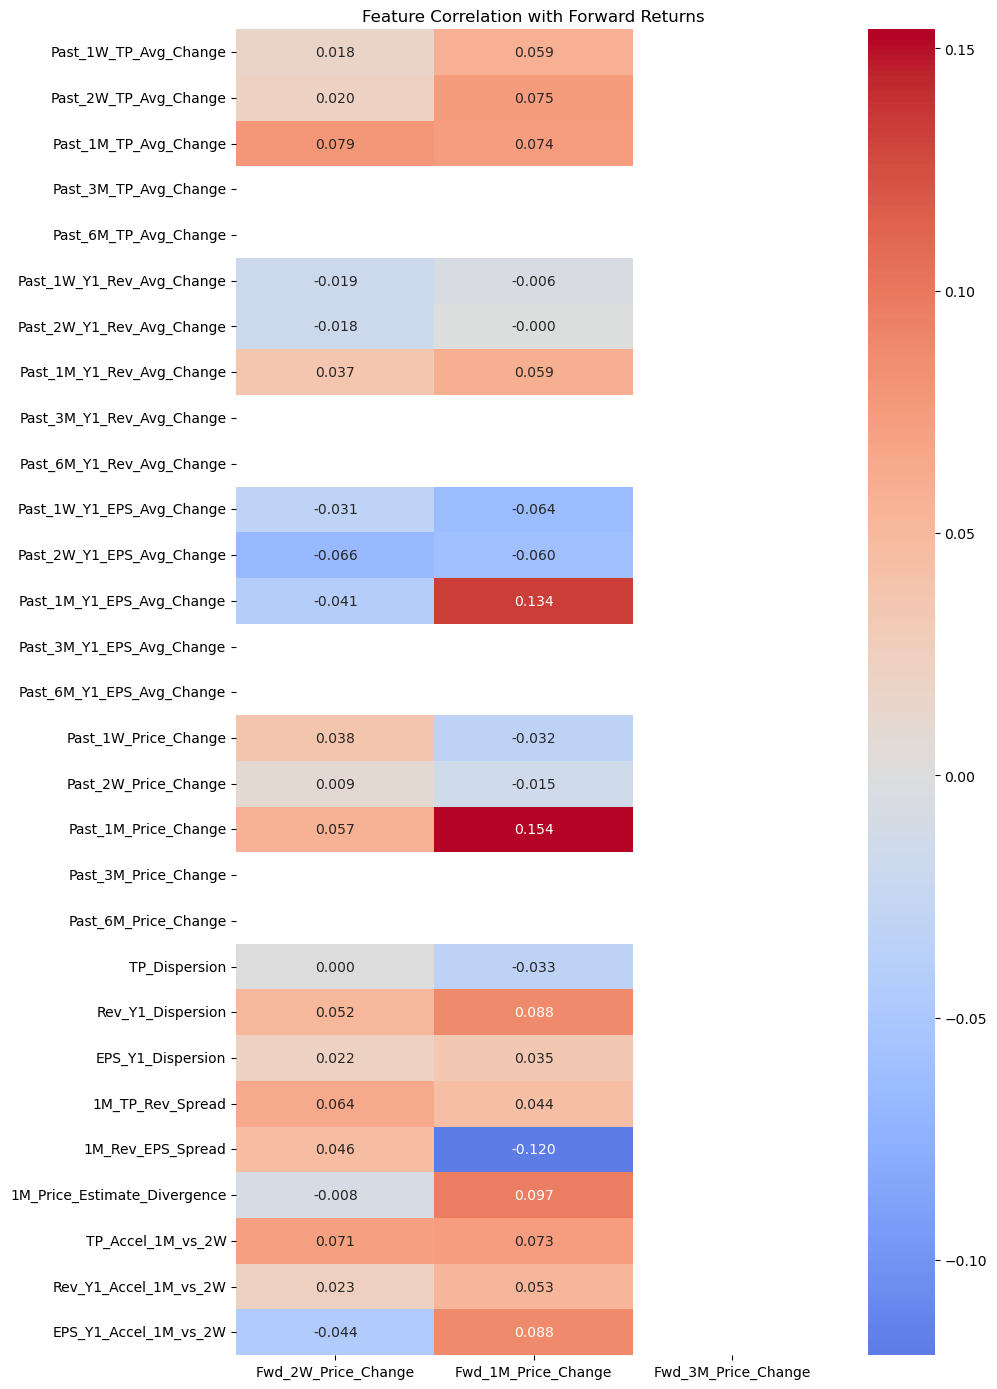

In [3]:
# ================= CELL 2: FEATURE CORRELATION ANALYSIS =================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(output_file, parse_dates=["Date"])

# Target variables
targets = ["Fwd_2W_Price_Change", "Fwd_1M_Price_Change", "Fwd_3M_Price_Change"]

# Select key features for correlation analysis (not all 150+ features)
key_features = [
    # Past revisions (Avg only, all windows)
    "Past_1W_TP_Avg_Change", "Past_2W_TP_Avg_Change", "Past_1M_TP_Avg_Change", 
    "Past_3M_TP_Avg_Change", "Past_6M_TP_Avg_Change",
    
    "Past_1W_Y1_Rev_Avg_Change", "Past_2W_Y1_Rev_Avg_Change", "Past_1M_Y1_Rev_Avg_Change",
    "Past_3M_Y1_Rev_Avg_Change", "Past_6M_Y1_Rev_Avg_Change",
    
    "Past_1W_Y1_EPS_Avg_Change", "Past_2W_Y1_EPS_Avg_Change", "Past_1M_Y1_EPS_Avg_Change",
    "Past_3M_Y1_EPS_Avg_Change", "Past_6M_Y1_EPS_Avg_Change",
    
    # Price momentum
    "Past_1W_Price_Change", "Past_2W_Price_Change", "Past_1M_Price_Change",
    "Past_3M_Price_Change", "Past_6M_Price_Change",
    
    # Dispersion
    "TP_Dispersion", "Rev_Y1_Dispersion", "EPS_Y1_Dispersion",
    
    # Interactions (1M window)
    "1M_TP_Rev_Spread", "1M_Rev_EPS_Spread", "1M_Price_Estimate_Divergence",
    
    # Accelerations
    "TP_Accel_1M_vs_2W", "Rev_Y1_Accel_1M_vs_2W", "EPS_Y1_Accel_1M_vs_2W",
]

# Filter to existing columns
key_features = [f for f in key_features if f in df.columns]

# Drop rows where all targets are NaN
df_corr = df.dropna(subset=targets, how="all")

# Compute correlation matrix
corr = df_corr[key_features + targets].corr()

# Extract feature ↔ target correlations
corr_with_targets = corr[targets].loc[key_features]

print("\n=== Correlation of Features with Forward Returns ===")
print(corr_with_targets.sort_values("Fwd_1M_Price_Change", ascending=False))

# Heatmap
plt.figure(figsize=(10, 14))
sns.heatmap(corr_with_targets, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Feature Correlation with Forward Returns")
plt.tight_layout()
plt.show()

In [4]:
# ================= CELL 3: MODEL COMPARISON (Lasso, RandomForest, XGBoost) =================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    print("⚠️  XGBoost not installed. Install with: pip install xgboost")
    HAS_XGBOOST = False

# Load dataset
df = pd.read_csv(output_file, parse_dates=["Date"])

# Target
target = "Fwd_1M_Price_Change"

# Feature selection: use key features (not all 150+)
feature_cols = [
    "Past_1W_TP_Avg_Change", "Past_1M_TP_Avg_Change", "Past_3M_TP_Avg_Change",
    "Past_1W_Y1_Rev_Avg_Change", "Past_1M_Y1_Rev_Avg_Change",
    "Past_1W_Y1_EPS_Avg_Change", "Past_1M_Y1_EPS_Avg_Change",
    "Past_1W_Price_Change", "Past_1M_Price_Change",
    "TP_Dispersion", "Rev_Y1_Dispersion", "EPS_Y1_Dispersion",
    "1M_TP_Rev_Spread", "1M_Price_Estimate_Divergence",
    "TP_Accel_1M_vs_2W", "Rev_Y1_Accel_1M_vs_2W",
]

# Filter to existing columns
feature_cols = [f for f in feature_cols if f in df.columns]

# Keep rows where target exists
df_reg = df.dropna(subset=[target]).copy()

# Drop rows with NaNs in features
df_reg = df_reg.dropna(subset=feature_cols)

print(f"Rows available for regression: {len(df_reg)}")
print(f"Features used: {len(feature_cols)}")

if len(df_reg) < 50:
    print("⚠️  Very small dataset. Results will be noisy. Wait for more data accumulation.")

X = df_reg[feature_cols]
y = df_reg[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42
)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

# ========== MODEL 1: LASSO ==========
lasso = Lasso(alpha=0.001, max_iter=5000, random_state=42)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"\n{'='*60}")
print("LASSO REGRESSION")
print(f"{'='*60}")
print(f"R² Score:  {r2_lasso:.4f}")
print(f"RMSE:      {rmse_lasso:.4f}")
print(f"MAE:       {mae_lasso:.4f}")

# Feature importance
lasso_coefs = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lasso.coef_
}).sort_values("Coefficient", key=abs, ascending=False)
print("\nTop 10 Lasso Coefficients:")
print(lasso_coefs.head(10).to_string(index=False))

# ========== MODEL 2: RANDOM FOREST ==========
rf = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_split=10,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)  # No scaling needed for tree models
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"\n{'='*60}")
print("RANDOM FOREST")
print(f"{'='*60}")
print(f"R² Score:  {r2_rf:.4f}")
print(f"RMSE:      {rmse_rf:.4f}")
print(f"MAE:       {mae_rf:.4f}")

# Feature importance
rf_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)
print("\nTop 10 RF Feature Importances:")
print(rf_importance.head(10).to_string(index=False))

# ========== MODEL 3: XGBOOST ==========
if HAS_XGBOOST:
    xgb = XGBRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    
    r2_xgb = r2_score(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    
    print(f"\n{'='*60}")
    print("XGBOOST")
    print(f"{'='*60}")
    print(f"R² Score:  {r2_xgb:.4f}")
    print(f"RMSE:      {rmse_xgb:.4f}")
    print(f"MAE:       {mae_xgb:.4f}")
    
    # Feature importance
    xgb_importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": xgb.feature_importances_
    }).sort_values("Importance", ascending=False)
    print("\nTop 10 XGBoost Feature Importances:")
    print(xgb_importance.head(10).to_string(index=False))

# ========== MODEL COMPARISON ==========
print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")
comparison = pd.DataFrame({
    "Model": ["Lasso", "Random Forest", "XGBoost"] if HAS_XGBOOST else ["Lasso", "Random Forest"],
    "R²": [r2_lasso, r2_rf, r2_xgb] if HAS_XGBOOST else [r2_lasso, r2_rf],
    "RMSE": [rmse_lasso, rmse_rf, rmse_xgb] if HAS_XGBOOST else [rmse_lasso, rmse_rf],
    "MAE": [mae_lasso, mae_rf, mae_xgb] if HAS_XGBOOST else [mae_lasso, mae_rf],
})
print(comparison.to_string(index=False))
print(f"\nBest R²: {comparison['Model'].iloc[comparison['R²'].idxmax()]} ({comparison['R²'].max():.4f})")

Rows available for regression: 0
Features used: 16
⚠️  Very small dataset. Results will be noisy. Wait for more data accumulation.


ValueError: With n_samples=0, test_size=0.25 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [7]:
# ================= CELL 4: QUICK STATS & DATA QUALITY CHECK =================
import pandas as pd
import numpy as np

df = pd.read_csv(output_file, parse_dates=["Date"])

print(f"{'='*70}")
print("FACTOR DATASET SUMMARY")
print(f"{'='*70}")
print(f"Total rows: {len(df)}")
print(f"Total features: {len(df.columns)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Unique tickers: {df['YAHOO Ticker'].nunique()}")
print(f"Unique dates: {df['Date'].nunique()}")

# Missing data per column
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(f"\nFeatures with >50% missing data:")
high_missing = missing_pct[missing_pct > 50]
if len(high_missing) > 0:
    for col, pct in high_missing.head(10).items():
        print(f"  {col}: {pct:.1f}%")
else:
    print("  None (good!)")

# Target variable availability
print(f"\nTarget variable availability:")
for col in ["Fwd_2W_Price_Change", "Fwd_1M_Price_Change", "Fwd_3M_Price_Change"]:
    avail = df[col].notna().sum()
    pct = avail / len(df) * 100
    print(f"  {col}: {avail} rows ({pct:.1f}%)")

print(f"\n✅ Data quality check complete!")

FACTOR DATASET SUMMARY
Total rows: 2298
Total features: 118
Date range: 2026-01-09 to 2026-03-20
Unique tickers: 236
Unique dates: 10

Features with >50% missing data:
  Past_3M_Y1_Rev_Min_Change: 100.0%
  Past_3M_TP_Min_Change: 100.0%
  Past_6M_Y1_Rev_Max_Change: 100.0%
  Past_6M_Y1_Rev_Avg_Change: 100.0%
  Past_6M_Y1_Rev_Min_Change: 100.0%
  Past_6M_TP_Max_Change: 100.0%
  Past_6M_TP_Avg_Change: 100.0%
  Past_6M_TP_Min_Change: 100.0%
  Past_3M_Price_Change: 100.0%
  Past_3M_Y2_EPS_Max_Change: 100.0%

Target variable availability:
  Fwd_2W_Price_Change: 1828 rows (79.5%)
  Fwd_1M_Price_Change: 1361 rows (59.2%)
  Fwd_3M_Price_Change: 0 rows (0.0%)

✅ Data quality check complete!
